# SalesInsight PY — Visualização dos Dados de Vendas

## `RF08` — Criar e Exportar Visualizações

Este notebook apresenta visualmente os principais resultados do SalesInsight PY. As análises utilizam o dataset já limpo e transformado, armazenado em `data/processed`, sem repetir as etapas de tratamento realizadas no notebook principal.

Serão produzidos gráficos de linha, barras e dispersão, além de um painel com quatro visualizações. Cada figura será apresentada no notebook e exportada em formato PNG para `reports/figures`.

## 1. Preparação do Ambiente

Nesta etapa serão importadas as bibliotecas utilizadas na leitura dos dados e na construção das visualizações. A função `salvar_figura()` será responsável por padronizar a exportação das figuras.


In [14]:
from pathlib import Path
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sales_insight.visualizacao import salvar_figura

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

## 2. Carregamento dos Dados Processados

O arquivo `vendas_processado.csv` contém os registros resultantes das etapas de limpeza e transformação. A partir dele serão preparadas somente as métricas necessárias para cada visualização.


In [3]:
caminho_dados = Path("../data/processed/vendas_processado.csv")

if not caminho_dados.exists():
    raise FileNotFoundError(
        f"Arquivo processado não encontrado: {caminho_dados.resolve()}"
    )

df = pd.read_csv(caminho_dados)

print(f"Registros carregados: {len(df):,}")
print(f"Colunas disponíveis: {df.shape[1]}")

Registros carregados: 5,361
Colunas disponíveis: 22


In [4]:
df.head(3)

,id_venda,data_venda,mes_venda,bimestre,id_cliente,nome_cliente,cidade,estado,regiao,id_produto,...,quantidade,preco_unitario,receita_total,faixa_receita_item,desconto,valor_desconto,previsao_entrega,data_entrega,desvio_entrega_dias,atrasado
0,ORD00001,2025-01-01,Janeiro,B1,Cliente_008,Thales Pereira,Cascavel,PR,Sul,P0005,...,1,124.91,120.83,Baixo Valor,0.0327,4.08,2025-01-07,2025-01-09,2,True
1,ORD00002,2025-01-01,Janeiro,B1,Cliente_011,Julia Ribeiro,Santa Maria,RS,Sul,P0006,...,4,129.86,494.68,Baixo Valor,0.0477,24.76,2025-01-04,2025-01-08,4,True
2,ORD00003,2025-01-01,Janeiro,B1,Cliente_019,Gabriela da Paz,Uberlândia,MG,Sudeste,P0002,...,2,1799.01,3065.16,Médio Valor,0.1481,532.86,2025-01-05,2025-01-04,-1,False


## 3. Evolução da Receita Mensal

### Como a receita total evoluiu ao longo dos meses?

A primeira visualização apresentará a receita acumulada em cada mês do período analisado. Para isso, os registros serão agrupados por `mes_venda`, somando os valores de `receita_total`.

O resultado será ordenado cronologicamente e representado em um gráfico de linha, permitindo identificar aumentos, reduções e o mês de maior receita.


In [13]:
receita_mensal = df.groupby("mes_venda", as_index=False).agg(
    receita_total=("receita_total", "sum")
)

ordem_meses = [
    "Janeiro",
    "Fevereiro",
    "Março",
    "Abril",
    "Maio",
    "Junho",
]

receita_mensal["mes_venda"] = pd.Categorical(
    receita_mensal["mes_venda"],
    categories=ordem_meses,
    ordered=True,
)

receita_mensal = receita_mensal.sort_values("mes_venda").reset_index(drop=True)

receita_mensal.head(6).style.hide(axis="index").format({"receita_total": "{:_.2f}"})

mes_venda,receita_total
Janeiro,1_299_266.31
Fevereiro,1_591_691.83
Março,2_291_715.46
Abril,2_004_674.61
Maio,1_613_016.68
Junho,1_537_652.30


Figura salva em: /home/bruno/Desktop/SC_TECH/mini_projeto/sales_insight/reports/figures/receita_por_mes.png


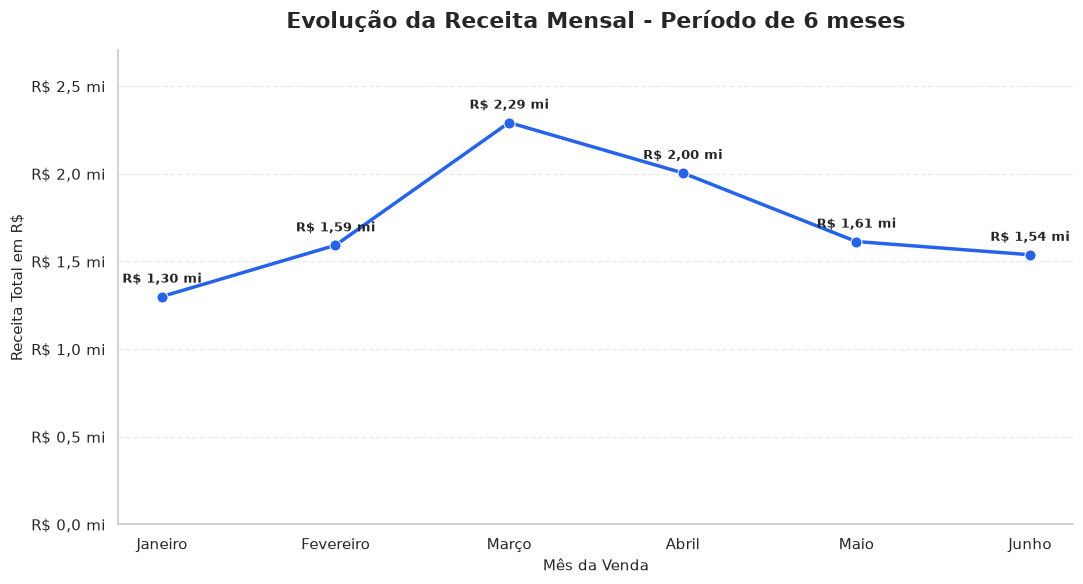

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=receita_mensal,
    x="mes_venda",
    y="receita_total",
    marker="o",
    markersize=8,
    lw=2.5,
    color="#2563eb",
    ax=ax,
)

ax.set_title(
    "Evolução da Receita Mensal - Período de 6 meses",
    fontsize=16,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel("Mês da Venda", fontsize=11)

ax.set_ylabel("Receita Total em R$", fontsize=11)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: (f"R$ {valor / 1_000_000:.1f} mi".replace(".", ",")))
)

for indice, receita in enumerate(receita_mensal["receita_total"]):
    rotulo = f"R$ {receita / 1_000_000:.2f} mi".replace(".", ",")

    ax.annotate(
        rotulo,
        xy=(indice, receita),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_ylim(
    0,
    receita_mensal["receita_total"].max() * 1.18,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

ax.grid(
    axis="x",
    visible=False,
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
)

fig.tight_layout()

caminho_figura = salvar_figura(
    fig,
    "receita_por_mes.png",
)

print(f"Figura salva em: {caminho_figura}")

plt.show()

## 4. Produtos com Maior Receita

### Quais produtos geraram as maiores receitas no período?

As vendas serão agrupadas por produto e suas receitas serão acumuladas. Após a ordenação decrescente, os cinco produtos com maior receita serão apresentados em um gráfico de barras horizontais.

Esse formato facilita a comparação dos valores e mantém legíveis os nomes mais extensos dos produtos.


In [17]:
top_5_produtos = (
    df.groupby(
        "produto",
        as_index=False,
    )
    .agg(
        receita_total=("receita_total", "sum"),
    )
    .sort_values(
        "receita_total",
        ascending=False,
    )
    .head(5)
    .reset_index(drop=True)
)

display(top_5_produtos.style.hide(axis="index").format({"receita_total": "R$ {:,.2f}"}))

produto,receita_total
ACER Notebook Gamer Nitro,"R$ 1,848,972.94"
"Projetor Smart Epson EpiqVision, FULL HD","R$ 1,244,636.36"
Samsung Galaxy A36,"R$ 850,244.53"
Samsung Galaxy Tab S6 Lite,"R$ 839,934.77"
Projetor EPSON Powerlite Wide Screen,"R$ 801,184.04"


Figura salva em: /home/bruno/Desktop/SC_TECH/mini_projeto/sales_insight/reports/figures/top_produtos.png


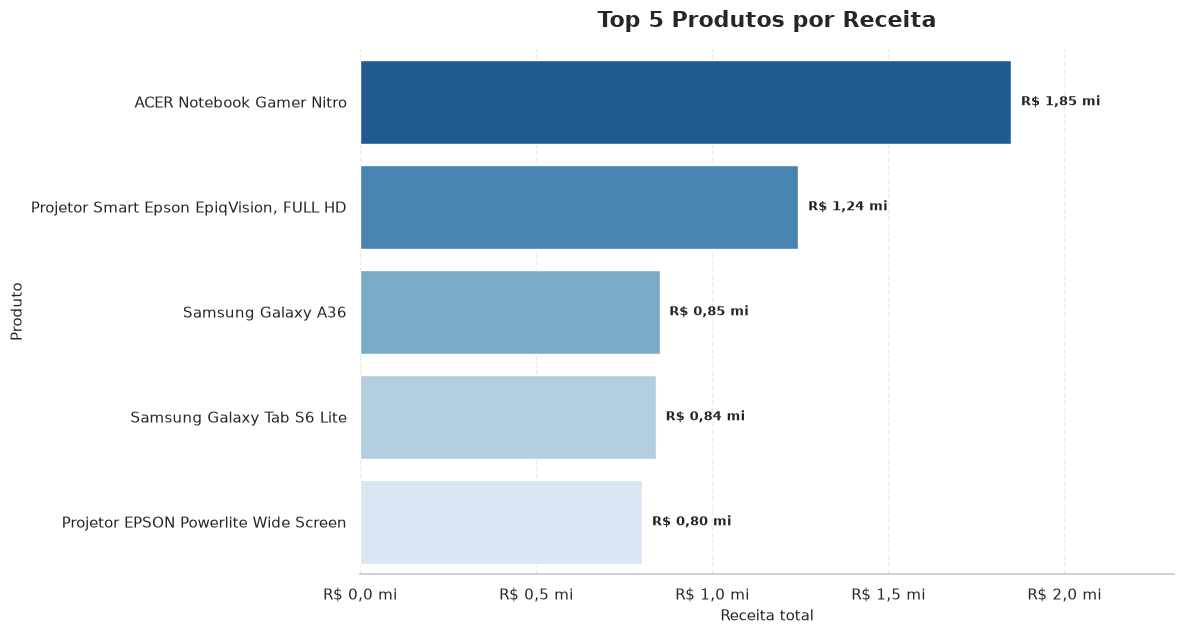

In [18]:
fig, ax = plt.subplots(figsize=(12, 6.5))

sns.barplot(
    data=top_5_produtos,
    x="receita_total",
    y="produto",
    hue="produto",
    palette="Blues_r",
    legend=False,
    order=top_5_produtos["produto"],
    ax=ax,
)

ax.set_title(
    "Top 5 Produtos por Receita",
    fontsize=16,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Receita total",
    fontsize=11,
)

ax.set_ylabel(
    "Produto",
    fontsize=11,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: (f"R$ {valor / 1_000_000:.1f} mi".replace(".", ",")))
)

maior_receita = top_5_produtos["receita_total"].max()

for barra in ax.patches:
    receita = barra.get_width()

    rotulo = f"R$ {receita / 1_000_000:.2f} mi".replace(".", ",")

    ax.text(
        receita + maior_receita * 0.015,
        barra.get_y() + barra.get_height() / 2,
        rotulo,
        va="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xlim(
    0,
    maior_receita * 1.25,
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
)

ax.grid(
    axis="y",
    visible=False,
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    left=True,
)

fig.tight_layout()

caminho_figura = salvar_figura(
    fig,
    "top_produtos.png",
)

print(f"Figura salva em: {caminho_figura}")

plt.show()

## 5. Relação entre Quantidade e Receita

### Como a quantidade vendida se relaciona com a receita de cada transação?

O gráfico de dispersão utilizará os registros individuais de venda, diferenciando as categorias por cor.


Figura salva em: /home/bruno/Desktop/SC_TECH/mini_projeto/sales_insight/reports/figures/quantidade_vs_receita.png


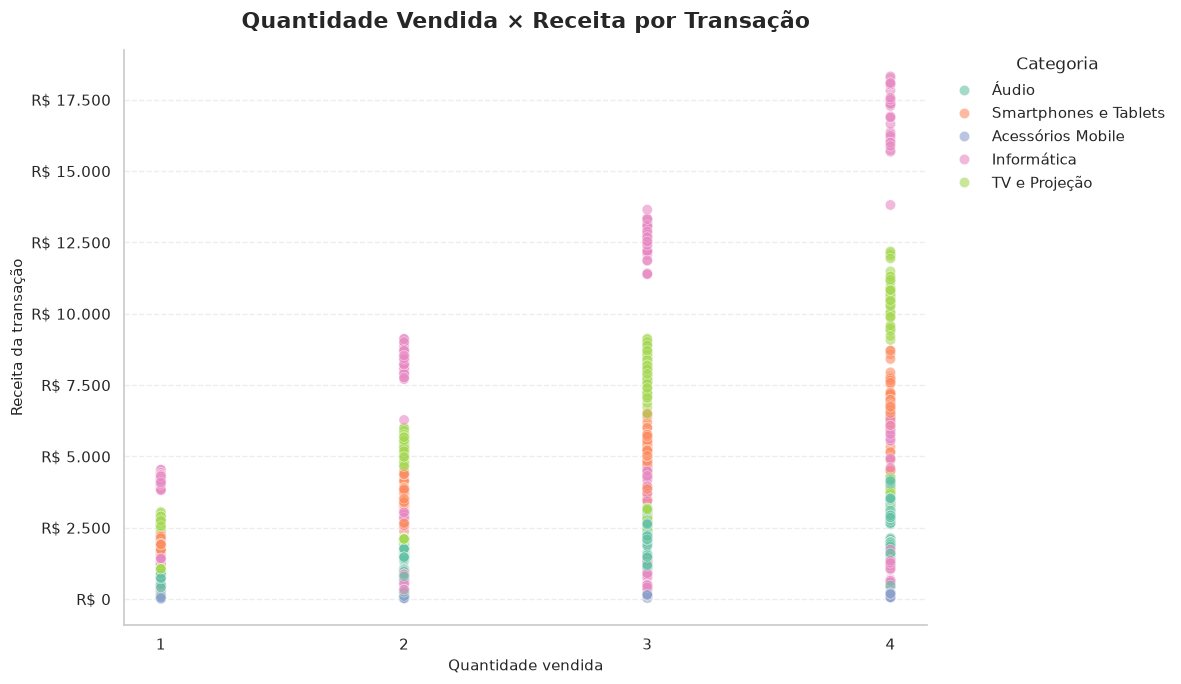

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="quantidade",
    y="receita_total",
    hue="categoria",
    palette="Set2",
    alpha=0.6,
    s=55,
    edgecolor="white",
    linewidth=0.4,
    ax=ax,
)

ax.set_title(
    "Quantidade Vendida × Receita por Transação",
    fontsize=16,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Quantidade vendida",
    fontsize=11,
)

ax.set_ylabel(
    "Receita da transação",
    fontsize=11,
)

ax.set_xticks(sorted(df["quantidade"].unique()))

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: (f"R$ {valor:,.0f}".replace(",", ".")))
)

ax.legend(
    title="Categoria",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35,
)

ax.grid(
    axis="x",
    visible=False,
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
)

fig.tight_layout()

caminho_figura = salvar_figura(
    fig,
    "quantidade_vs_receita.png",
)

print(f"Figura salva em: {caminho_figura}")

plt.show()

## 6. Quais cidades concentram mais vendas e receita?

Para comparar o desempenho geográfico, serão construídos dois rankings: as dez cidades com maior número de vendas e as dez cidades com maior receita total. O agrupamento considera cidade e estado para evitar a união de municípios homônimos.


In [25]:
metricas_cidades = df.groupby(["cidade", "estado"], as_index=False).agg(
    numero_vendas=("id_venda", "nunique"),
    receita_total=("receita_total", "sum"),
)

metricas_cidades["cidade_uf"] = (
    metricas_cidades["cidade"] + " - " + metricas_cidades["estado"]
)

top_10_vendas = (
    metricas_cidades.sort_values(
        ["numero_vendas", "receita_total"],
        ascending=[False, False],
    )
    .head(10)
    .reset_index(drop=True)
)

top_10_receita = (
    metricas_cidades.sort_values(
        ["receita_total", "numero_vendas"],
        ascending=[False, False],
    )
    .head(10)
    .reset_index(drop=True)
)

In [27]:
top_10_receita

,cidade,estado,numero_vendas,receita_total,cidade_uf
0,Ribeirão Preto,SP,215,440532.38,Ribeirão Preto - SP
1,Cascavel,PR,176,308822.32,Cascavel - PR
2,Blumenau,SC,120,284718.32,Blumenau - SC
3,Duque de Caxias,RJ,119,279927.42,Duque de Caxias - RJ
4,Londrina,PR,127,260428.33,Londrina - PR
5,Maringá,PR,142,245174.14,Maringá - PR
6,Vila Velha,ES,132,236950.45,Vila Velha - ES
7,Pelotas,RS,124,233806.93,Pelotas - RS
8,Uberlândia,MG,113,216226.10,Uberlândia - MG
9,Joinville,SC,88,216118.79,Joinville - SC


Figura salva em: /home/bruno/Desktop/SC_TECH/mini_projeto/sales_insight/reports/figures/top_cidades_vendas_receita.png


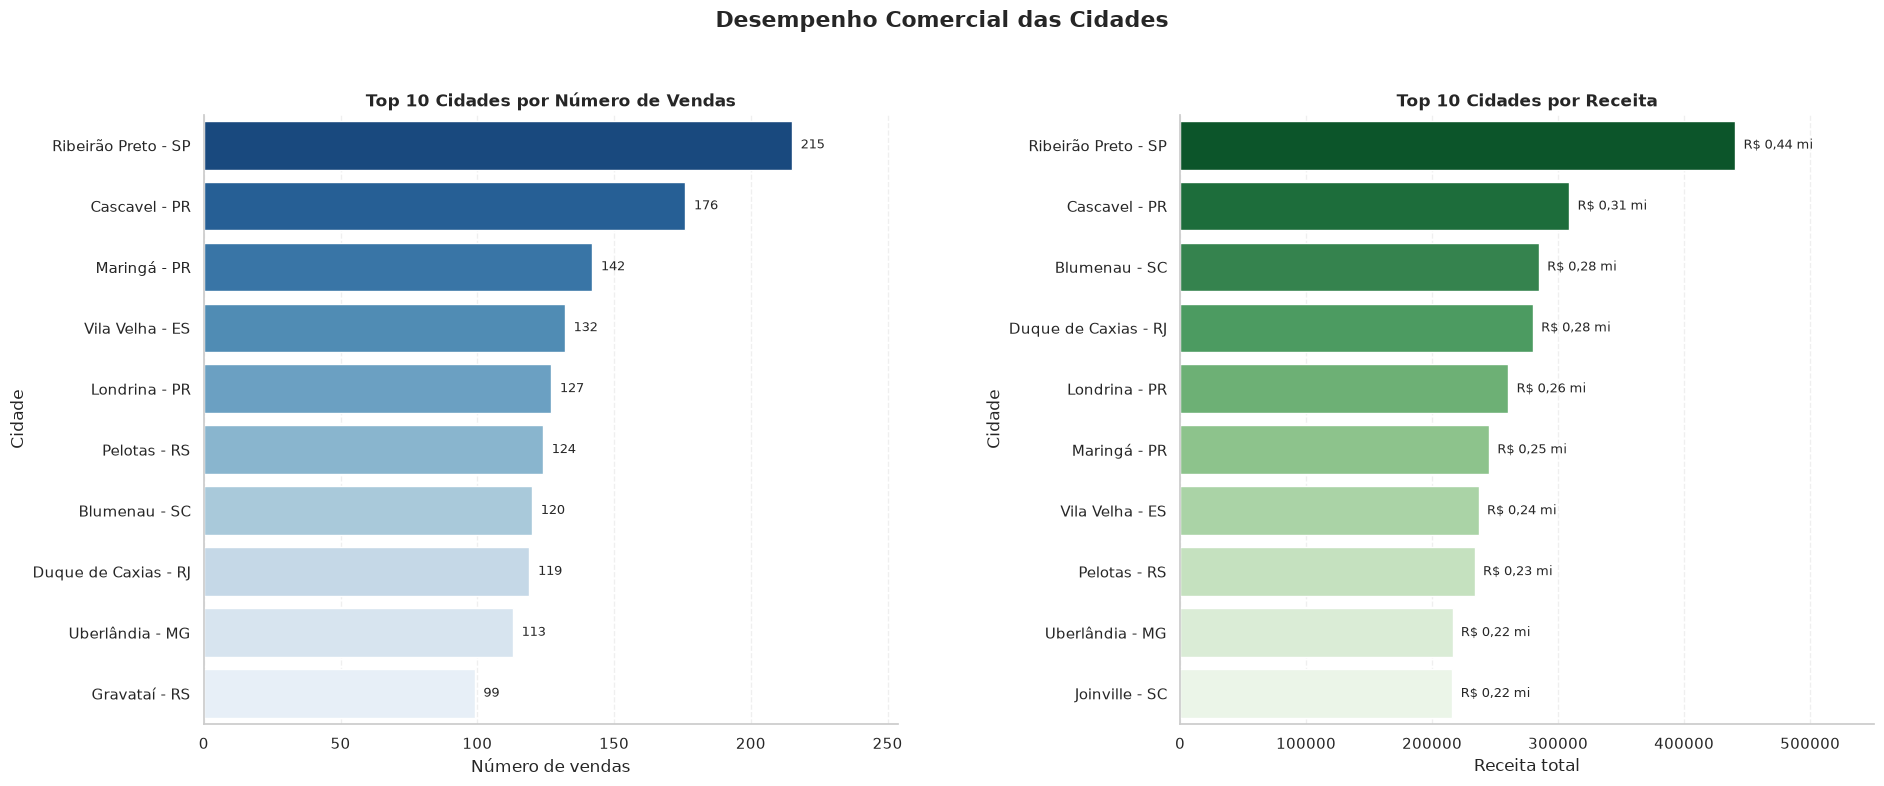

In [28]:
fig, (ax_vendas, ax_receita) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(19, 8),
)

sns.barplot(
    data=top_10_vendas,
    x="numero_vendas",
    y="cidade_uf",
    hue="cidade_uf",
    palette="Blues_r",
    legend=False,
    order=top_10_vendas["cidade_uf"],
    ax=ax_vendas,
)

sns.barplot(
    data=top_10_receita,
    x="receita_total",
    y="cidade_uf",
    hue="cidade_uf",
    palette="Greens_r",
    legend=False,
    order=top_10_receita["cidade_uf"],
    ax=ax_receita,
)

ax_vendas.set_title(
    "Top 10 Cidades por Número de Vendas",
    fontweight="bold",
)

ax_vendas.set_xlabel("Número de vendas")
ax_vendas.set_ylabel("Cidade")

ax_receita.set_title(
    "Top 10 Cidades por Receita",
    fontweight="bold",
)

ax_receita.set_xlabel("Receita total")
ax_receita.set_ylabel("Cidade")

maior_numero_vendas = top_10_vendas["numero_vendas"].max()

for barra in ax_vendas.patches:
    valor = barra.get_width()

    ax_vendas.text(
        valor + maior_numero_vendas * 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor)}",
        va="center",
        fontsize=9,
    )

maior_receita = top_10_receita["receita_total"].max()

for barra in ax_receita.patches:
    valor = barra.get_width()
    rotulo = f"R$ {valor / 1_000_000:.2f} mi".replace(".", ",")

    ax_receita.text(
        valor + maior_receita * 0.015,
        barra.get_y() + barra.get_height() / 2,
        rotulo,
        va="center",
        fontsize=9,
    )

ax_vendas.set_xlim(0, maior_numero_vendas * 1.18)
ax_receita.set_xlim(0, maior_receita * 1.25)

ax_vendas.grid(axis="x", linestyle="--", alpha=0.3)
ax_receita.grid(axis="x", linestyle="--", alpha=0.3)

sns.despine(ax=ax_vendas)
sns.despine(ax=ax_receita)

fig.suptitle(
    "Desempenho Comercial das Cidades",
    fontsize=16,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.95], w_pad=5)

caminho_figura = salvar_figura(
    fig,
    "top_cidades_vendas_receita.png",
)

print(f"Figura salva em: {caminho_figura}")

plt.show()